# Importing Libraries

In [2]:
# 自动获取当前Jupyter的Python解释器，安装所有依赖
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn plotly statsmodels scikit-learn imbalanced-learn scipy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB 1.3 MB/s eta 0:00:08
   ---------------------------------------- 0.1/9.5 MB 1.3 MB/s eta 0:00:08
    --------------------------------------- 0.2/9.5 MB 1.6 MB/s eta 0:00:07
    --------------------------------------- 0.2/9.5 MB 1.5 MB/s eta 0:00:07
    --------------------------------------- 0.2/9.5 MB 1.5 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/9.5 MB 1.9 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/9.5 MB 2.0 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.5 MB 2.2 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.5 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.1/9.5 MB 2.5 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.5/9.5 MB 2.8 MB/s eta 0:00:03
   ------- --------

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy.cluster.hierarchy import linkage, fcluster
import warnings
warnings.filterwarnings("ignore")

In [110]:
# !pip install openpyxl
# !pip install imblearn

# Import Dataset

In [111]:
df=pd.read_csv("HL_SC.csv")
df.head()

,prospect_no,loan_disb_date,asset_cost,disb_amt,down_payment,roi,age,is_exist_cust,dist_from_off,is_expat,...,locality,accommodation_type,current_residence,veh_own,foir,tenure,vin_in_business,ltv,target,random
0,1,21-11-2015,1467032,1100274,366758,16,48,0,29.0,0,...,Middle Class,Apartment,Owned,2,40,240,28,75,0,0.622896
1,2,05-11-2015,1113349,734810,378539,15,50,0,11.0,1,...,Below Avg,Villa,Rented,1,41,132,21,66,0,0.107378
2,3,01-12-2015,1660092,979454,680638,14,45,0,53.0,1,...,Below Avg,Villa,Rented,2,34,156,50,59,0,0.110078
3,4,06-10-2015,1061768,902503,159265,14,49,0,8.0,1,...,Middle Class,Apartment,Owned,2,41,120,19,85,0,0.144848
4,5,31-01-2015,1212534,836648,375886,19,36,0,48.0,0,...,Middle Class,Apartment,Owned,2,45,108,75,69,0,0.266234


# 探索性数据分析

In [112]:
df["target"].sum()

1399

In [113]:
df[df['marital_status'].isnull() & df['target']==1].shape

(64, 27)

In [114]:
df[df['dist_from_off'].isnull() & df['target']==1].shape

(16, 27)

In [115]:
df.shape

(20000, 27)

In [116]:
df.describe()

,prospect_no,asset_cost,disb_amt,down_payment,roi,age,is_exist_cust,dist_from_off,is_expat,children,earning_members,yrs_in_curr_resi,veh_own,foir,tenure,vin_in_business,ltv,target,random
count,20000.000000,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,19816.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,1.177247e+06,7.828082e+05,3.944387e+05,15.082650,45.015150,0.183000,23.180662,0.500000,2.095550,1.872300,4.699200,1.614000,44.559200,149.43360,38.860050,66.422200,0.069950,0.496697
std,5773.647028,3.331986e+05,2.743219e+05,2.081830e+05,3.052095,8.019479,0.386676,18.144472,0.500013,1.515399,1.043526,3.836086,0.631129,8.673082,57.14118,23.238809,14.024621,0.255069,0.289432
min,1.000000,3.011490e+05,1.301110e+05,1.733000e+04,8.000000,20.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,26.000000,60.00000,0.000000,40.000000,0.000000,0.000015
25%,5000.750000,9.762760e+05,5.996938e+05,2.400205e+05,12.000000,42.000000,0.000000,8.000000,0.000000,1.000000,1.000000,2.000000,1.000000,39.000000,96.00000,19.000000,55.000000,0.000000,0.245442
50%,10000.500000,1.188824e+06,7.849550e+05,3.685615e+05,15.000000,46.000000,0.000000,19.000000,0.500000,2.000000,1.000000,4.000000,2.000000,45.000000,144.00000,34.000000,66.000000,0.000000,0.493315
75%,15000.250000,1.385452e+06,9.489295e+05,5.280715e+05,18.000000,50.000000,0.000000,36.000000,1.000000,3.000000,3.000000,6.000000,2.000000,51.000000,180.00000,59.000000,76.000000,0.000000,0.748548
max,20000.000000,1.999756e+06,1.880934e+06,1.197307e+06,20.000000,60.000000,1.000000,68.000000,1.000000,7.000000,4.000000,20.000000,2.000000,66.000000,240.00000,200.000000,95.000000,1.000000,0.999991


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   prospect_no         20000 non-null  int64  
 1   loan_disb_date      20000 non-null  object 
 2   asset_cost          20000 non-null  int64  
 3   disb_amt            20000 non-null  int64  
 4   down_payment        20000 non-null  int64  
 5   roi                 20000 non-null  int64  
 6   age                 20000 non-null  int64  
 7   is_exist_cust       20000 non-null  int64  
 8   dist_from_off       19816 non-null  float64
 9   is_expat            20000 non-null  int64  
 10  children            20000 non-null  int64  
 11  earning_members     20000 non-null  int64  
 12  yrs_in_curr_resi    20000 non-null  int64  
 13  source_type         20000 non-null  object 
 14  marital_status      19025 non-null  object 
 15  gender              20000 non-null  object 
 16  appl

In [118]:
df.isnull().sum()

prospect_no             0
loan_disb_date          0
asset_cost              0
disb_amt                0
down_payment            0
roi                     0
age                     0
is_exist_cust           0
dist_from_off         184
is_expat                0
children                0
earning_members         0
yrs_in_curr_resi        0
source_type             0
marital_status        975
gender                  0
applicant_type          0
locality                0
accommodation_type      0
current_residence       0
veh_own                 0
foir                    0
tenure                  0
vin_in_business         0
ltv                     0
target                  0
random                  0
dtype: int64

### 缺失值插补

In [119]:
# Median Imputation
df['dist_from_off']=df['dist_from_off'].fillna(df['dist_from_off'].median())

### 数据集划分

In [120]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

dev, val, holdout = np.split(df.sample(frac=1, random_state=50),
                            [int(.5*len(df)),
                            int(.8*len(df))])
(len(dev),len(val),len(holdout))

(10000, 6000, 4000)

In [121]:
# Default rate distribution checking across all the samples
print("popln default rate:", round(sum(df.target)*100/len(df),2),'%')
print("dev default rate:", round(sum(dev.target)*100/len(dev),2),'%')
print("val default rate:", round(sum(val.target)*100/len(val),2),'%')
print("holdout default rate:", round(sum(holdout.target)*100/len(holdout),2),'%')


popln default rate: 7.0 %
dev default rate: 6.89 %
val default rate: 7.12 %
holdout default rate: 7.08 %


#### 与目标变量的相关性分析与多重共线性检测

Features correlated with target (numeric only):
target              1.000000
ltv                 0.124744
disb_amt            0.122108
dist_from_off       0.069168
asset_cost          0.051620
age                 0.035465
yrs_in_curr_resi    0.033054
tenure              0.025011
foir                0.024223
children            0.011167
veh_own             0.007770
random              0.006752
prospect_no         0.004207
is_expat           -0.000196
roi                -0.023035
is_exist_cust      -0.030934
earning_members    -0.037825
down_payment       -0.078284
vin_in_business    -0.083363
Name: target, dtype: float64


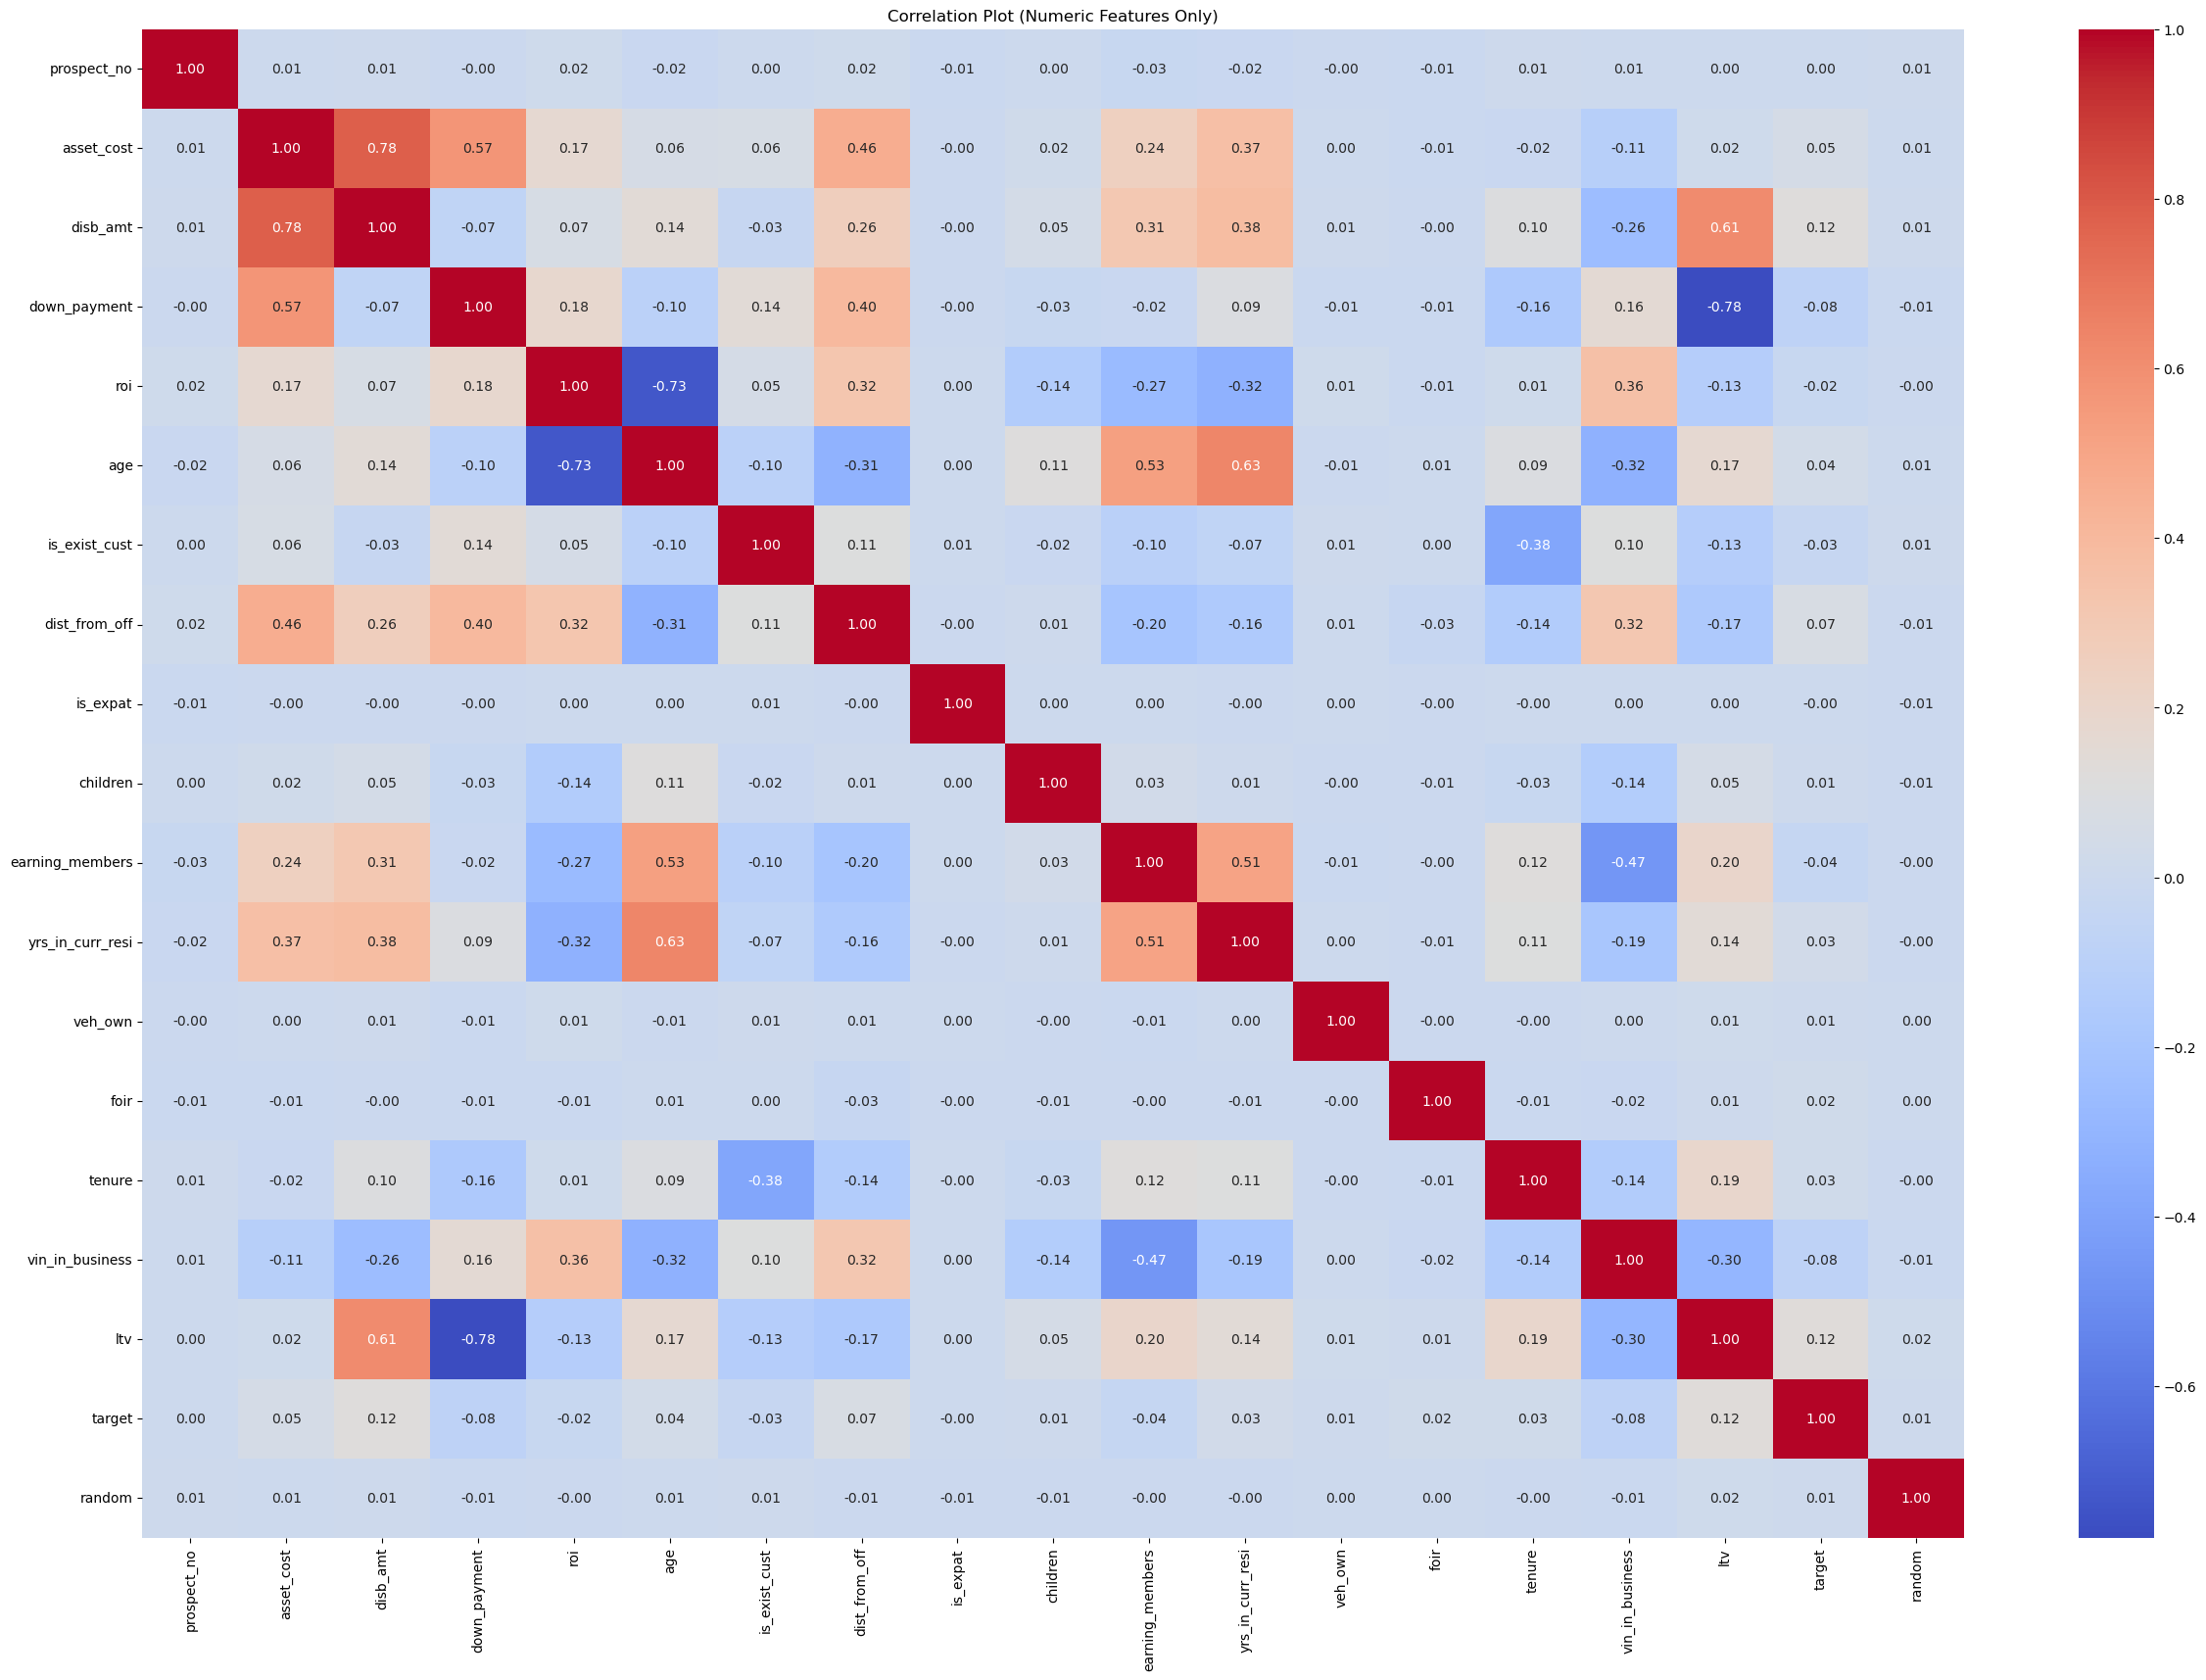

In [122]:
# 1. 从原数据中提取所有数值列
numeric_cols_df = df.select_dtypes(include=['number'])

# 2. 仅对数值列计算相关系数
correlation_matrix = numeric_cols_df.corr()

# 3. 提取与目标变量target的相关系数并排序（仅针对数值特征）
target_correlation = correlation_matrix['target'].sort_values(ascending=False)
print("Features correlated with target (numeric only):")
print(target_correlation)

plt.figure(figsize=(30, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Plot (Numeric Features Only)')
plt.show()

### WOE & IV 

In [123]:
# df["is_exist_cust"]=df["is_exist_cust"].astype(str)

In [124]:
# df["is_expat"]=df["is_expat"].astype(str)

In [125]:
def calculate_woe_iv(data, feature, target, bins=20, method='quantile'):
    data["is_exist_cust"]=data["is_exist_cust"].astype(str)
    data["is_expat"]=data["is_expat"].astype(str)
    # Bin the continuous variable if it's numeric
    if pd.api.types.is_numeric_dtype(data[feature]):
        if method == 'quantile':
            data[feature + '_binned'] = pd.qcut(data[feature], q=bins, duplicates='drop')
        elif method == 'uniform':
            data[feature + '_binned'] = pd.cut(data[feature], bins=bins)
        else:
            raise ValueError("Invalid binning method. Use 'quantile' or 'uniform'.")
        binned_feature = feature + '_binned'
    else:
        binned_feature = feature  # For categorical variables, use the feature as-is

    # Create a dataframe for the binned feature and target
    df = pd.DataFrame({binned_feature: data[binned_feature], target: data[target]})
    
    # Calculate the total bad_events (1) and good_events (0)
    total_bad_events = df[target].sum()
    total_good_events = df.shape[0] - total_bad_events

    # Calculate WOE and IV
    grouped = df.groupby(binned_feature)[target].agg(count='count', bad_events='sum')
    grouped['good_events'] = grouped['count'] - grouped['bad_events']
    
    # Calculate bad_event and good_event distribution
    grouped['bad_events_dist'] = grouped['bad_events'] / total_bad_events
    grouped['good_events_dist'] = grouped['good_events'] / total_good_events

    # Calculate WOE
    grouped['woe'] = np.log(grouped['good_events_dist'] / grouped['bad_events_dist'])
    
    # Calculate IV for each bin
    grouped['iv'] = (grouped['good_events_dist'] - grouped['bad_events_dist']) * grouped['woe']
    
    # Sum up the IV
    iv = grouped['iv'].sum()
    
    return grouped[['count', 'bad_events', 'good_events', 'bad_events_dist', 'good_events_dist', 'woe', 'iv']], iv


In [126]:
# calculate_woe_iv(dev,"is_exist_cust","target")

In [127]:
iv_values = []
feature_df = {}

# Loop through all features
for feature in dev.columns:
    if feature not in ['target', "prospect_no", "loan_disb_date"]:  # Exclude target column
        woe_iv_df, iv = calculate_woe_iv(dev, feature, 'target', bins=20, method='quantile')
        iv_values.append((feature, iv))
        feature_df[feature]=woe_iv_df
        print(f"WOE and IV for {feature}:\n", woe_iv_df)
        print(f"Information Value (IV) for {feature}: {iv}\n")        

# Summary of IV values for each feature
iv_df = pd.DataFrame(iv_values, columns=['Feature', 'IV']).sort_values(by='IV', ascending=False)
print("IV Values Summary:")
print(iv_df)

WOE and IV for asset_cost:
                          count  bad_events  good_events  bad_events_dist  \
asset_cost_binned                                                          
(302348.999, 560563.85]    500          20          480         0.029028   
(560563.85, 712305.1]      500          23          477         0.033382   
(712305.1, 821229.0]       500          29          471         0.042090   
(821229.0, 910218.6]       500          29          471         0.042090   
(910218.6, 974059.5]       500          33          467         0.047896   
(974059.5, 1032949.8]      500          27          473         0.039187   
(1032949.8, 1083702.8]     500          38          462         0.055152   
(1083702.8, 1123266.6]     500          31          469         0.044993   
(1123266.6, 1155158.45]    500          41          459         0.059507   
(1155158.45, 1187492.0]    500          21          479         0.030479   
(1187492.0, 1221176.8]     500          34          466     

In [128]:
# # Save all WOE/IV DataFrames to a single Excel file with each feature in a separate sheet
# with pd.ExcelWriter('woe_iv_output.xlsx') as writer:
#     for feature, df in feature_df.items():
#         df.to_excel(writer, sheet_name=feature, index=True)  # Each feature gets its own sheet
# #     print("WOE/IV data saved to 'woe_iv_output.xlsx'")
#     #Save the IV values summary to a separate sheet
#     iv_df.to_excel(writer, sheet_name='IV_Summary', index=False)
#     print("WOE/IV data and IV summary saved to 'woe_iv_output.xlsx'")

### 降维
基于IV选出特征

In [129]:
new_df = df[['ltv','disb_amt','vin_in_business','down_payment','dist_from_off','asset_cost','tenure','yrs_in_curr_resi','age','earning_members','roi','foir','target']]

In [130]:
new_df.head()

,ltv,disb_amt,vin_in_business,down_payment,dist_from_off,asset_cost,tenure,yrs_in_curr_resi,age,earning_members,roi,foir,target
0,75,1100274,28,366758,29.0,1467032,240,8,48,4,16,40,0
1,66,734810,21,378539,11.0,1113349,132,5,50,3,15,41,0
2,59,979454,50,680638,53.0,1660092,156,5,45,2,14,34,0
3,85,902503,19,159265,8.0,1061768,120,4,49,2,14,41,0
4,69,836648,75,375886,48.0,1212534,108,5,36,1,19,45,0


In [131]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ltv               20000 non-null  int64  
 1   disb_amt          20000 non-null  int64  
 2   vin_in_business   20000 non-null  int64  
 3   down_payment      20000 non-null  int64  
 4   dist_from_off     20000 non-null  float64
 5   asset_cost        20000 non-null  int64  
 6   tenure            20000 non-null  int64  
 7   yrs_in_curr_resi  20000 non-null  int64  
 8   age               20000 non-null  int64  
 9   earning_members   20000 non-null  int64  
 10  roi               20000 non-null  int64  
 11  foir              20000 non-null  int64  
 12  target            20000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 2.0 MB


In [132]:
new_df.columns

Index(['ltv', 'disb_amt', 'vin_in_business', 'down_payment', 'dist_from_off',
       'asset_cost', 'tenure', 'yrs_in_curr_resi', 'age', 'earning_members',
       'roi', 'foir', 'target'],
      dtype='object')

#### 标准化 + VIF 多重共线性检测

In [133]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(new_df), columns=new_df.columns)

# Calculating VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = df_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

# Display VIF scores
print(vif_data)

            Variable        VIF
0                ltv  13.299549
1           disb_amt        inf
2    vin_in_business   1.725273
3       down_payment        inf
4      dist_from_off   1.838938
5         asset_cost        inf
6             tenure   1.085106
7   yrs_in_curr_resi   2.308531
8                age   3.928814
9    earning_members   1.883327
10               roi   2.777928
11              foir   1.002276
12            target   1.051200


In [134]:
# sns.pairplot(new_df, hue="target", palette="coolwarm", height=3)
# plt.show()

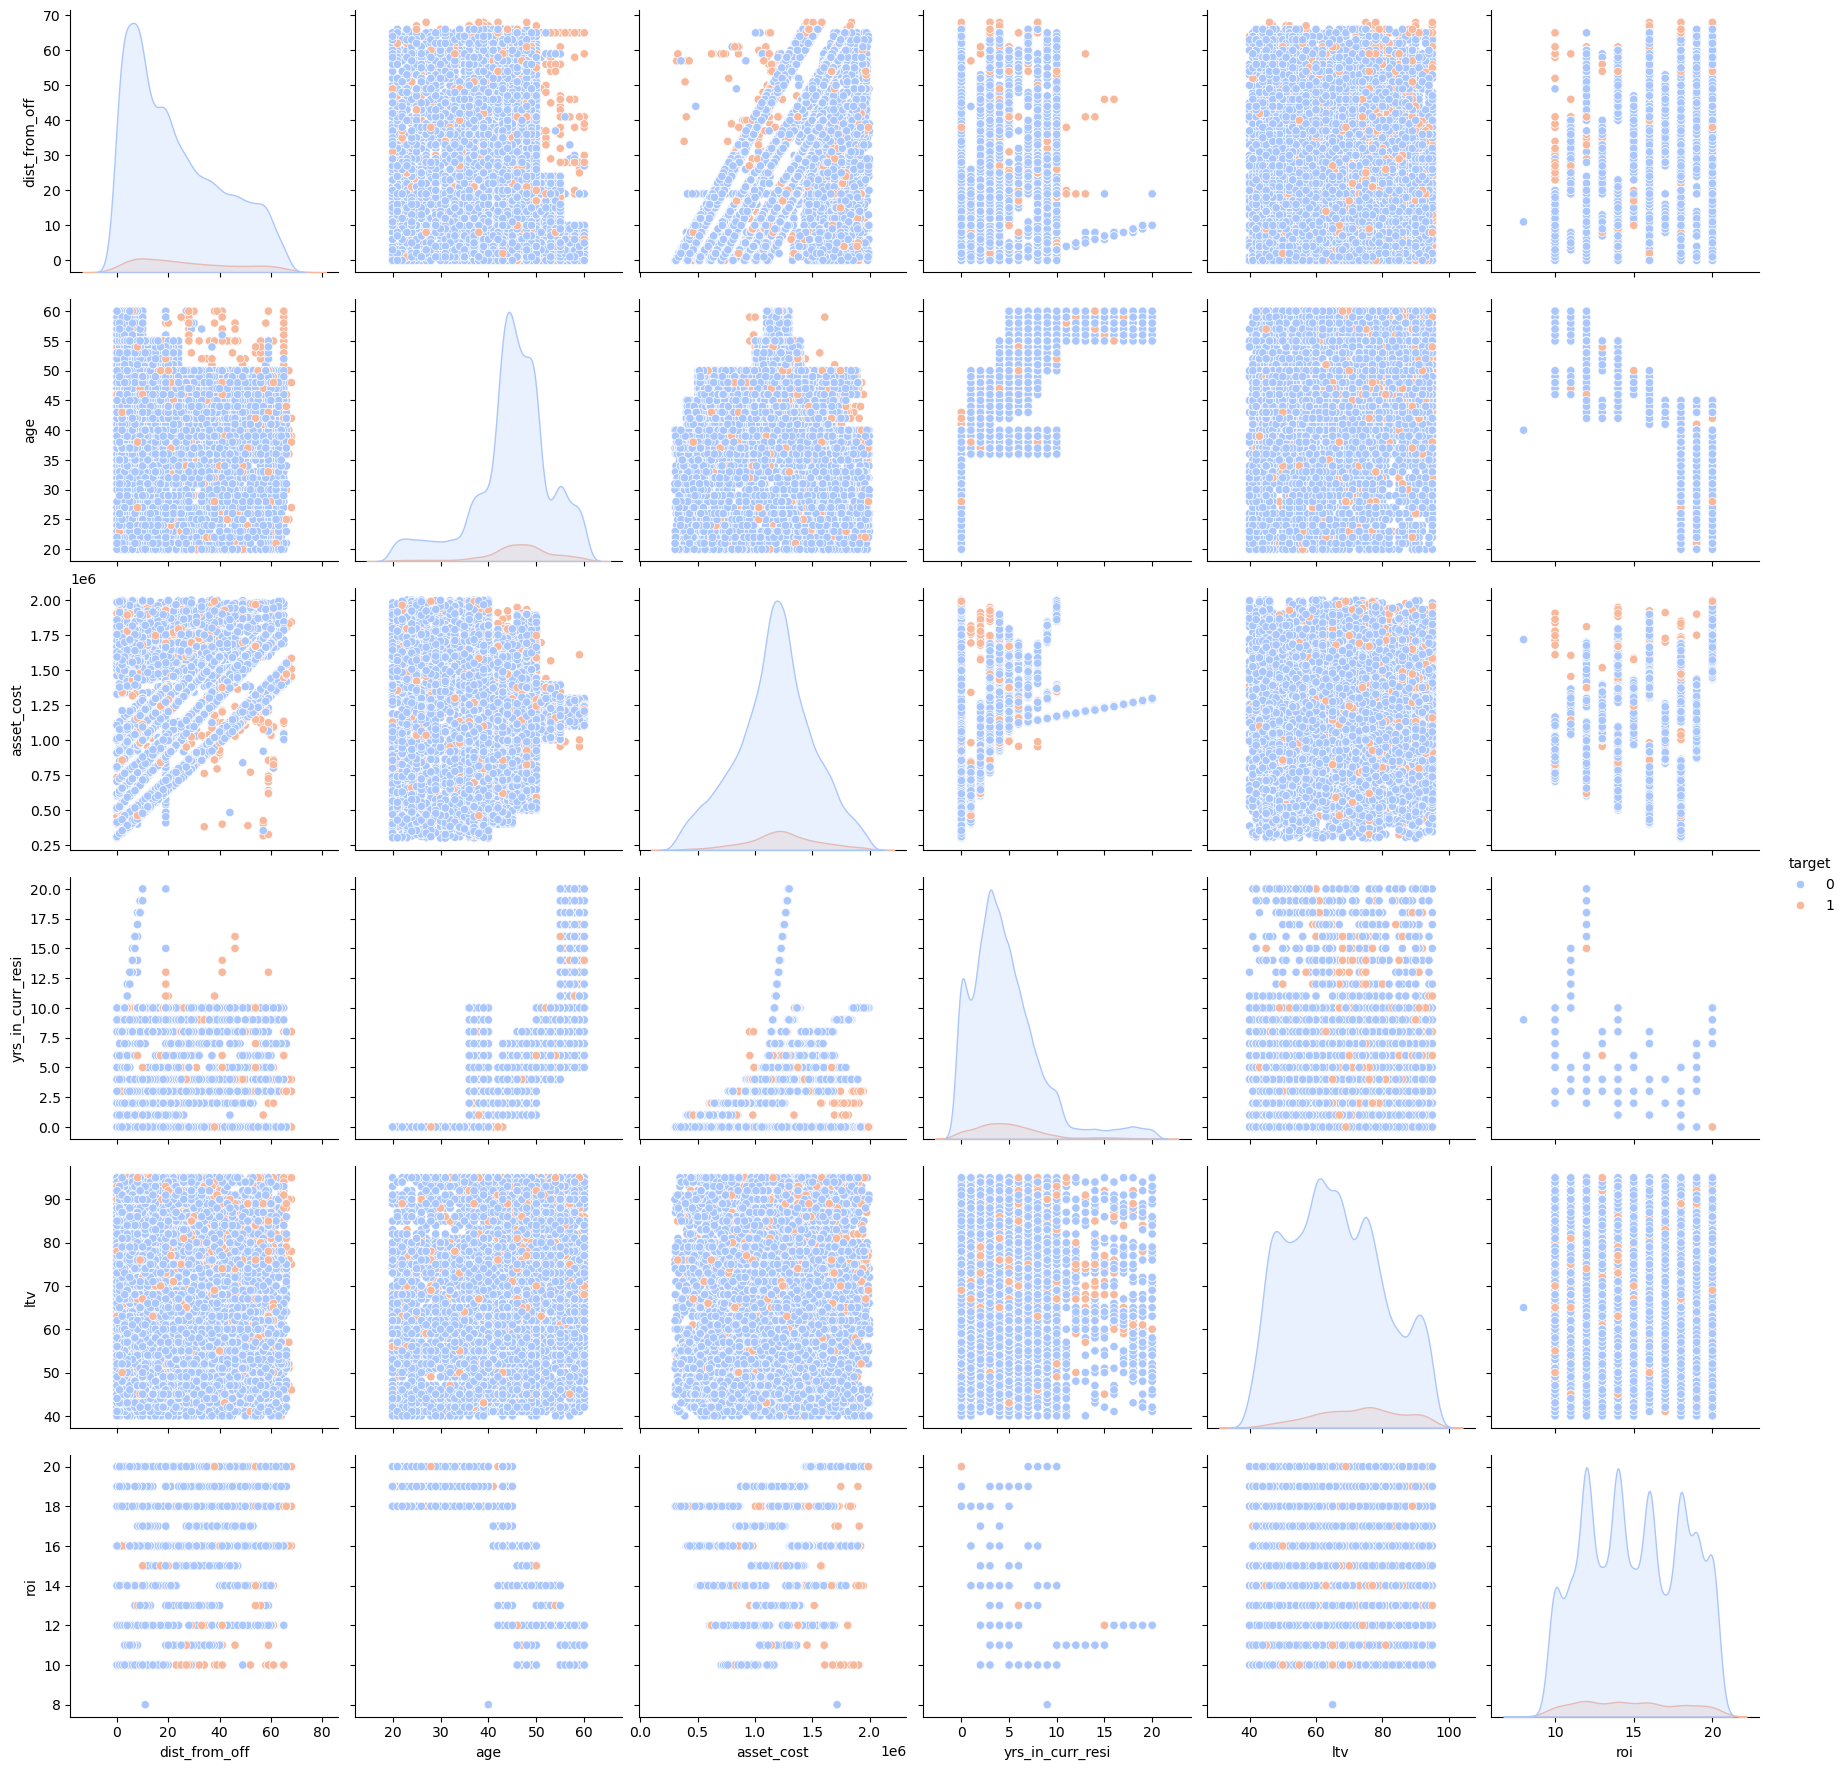

In [135]:
sns.pairplot(new_df[['dist_from_off','age','asset_cost','yrs_in_curr_resi','ltv', "roi", 'target']], hue="target", palette="coolwarm", height=3)
# plt.legend()
plt.show()

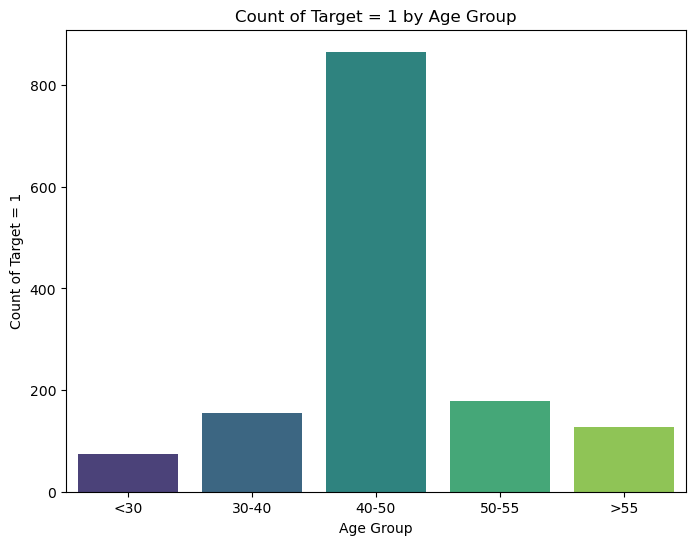

In [136]:
target_1_df = new_df[new_df['target'] == 1]

# Plot age groups without creating a new column
plt.figure(figsize=(8, 6))
sns.countplot(
    data=target_1_df, 
    x=pd.cut(target_1_df['age'], bins=[0, 30, 40, 50, 55, float('inf')], labels=['<30', '30-40', '40-50', '50-55', '>55']), 
    palette="viridis"
)
plt.title("Count of Target = 1 by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count of Target = 1")
plt.show()

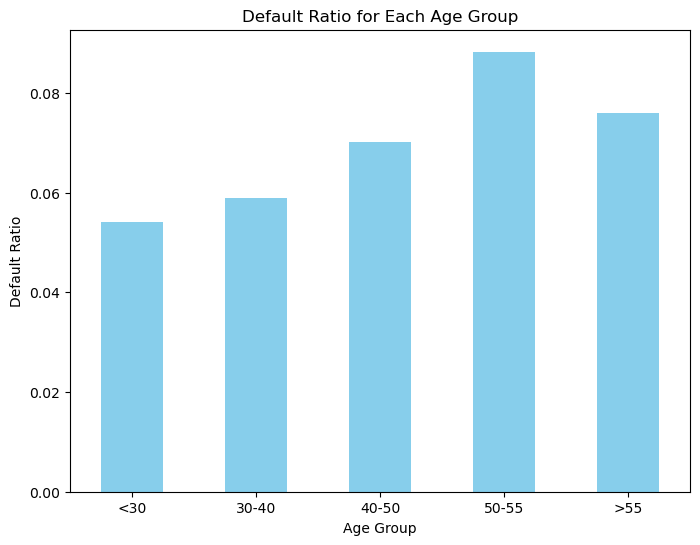

In [137]:
age_groups = pd.cut(new_df['age'], bins=[0, 30, 40, 50, 55, 100], labels=['<30', '30-40', '40-50', '50-55', '>55'])

# Calculate the ratio of target = 1 for each age group
age_group_ratio = new_df.groupby(age_groups)['target'].mean()

# Plot the barplot
plt.figure(figsize=(8, 6))
age_group_ratio.plot(kind='bar', color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Default Ratio')
plt.title('Default Ratio for Each Age Group')
plt.xticks(rotation=0)
plt.show()

### 异常值检测

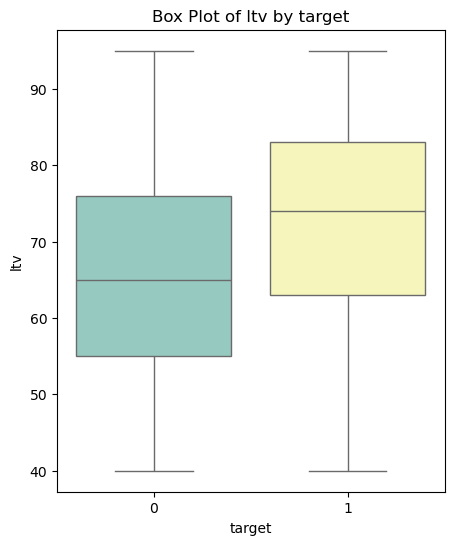

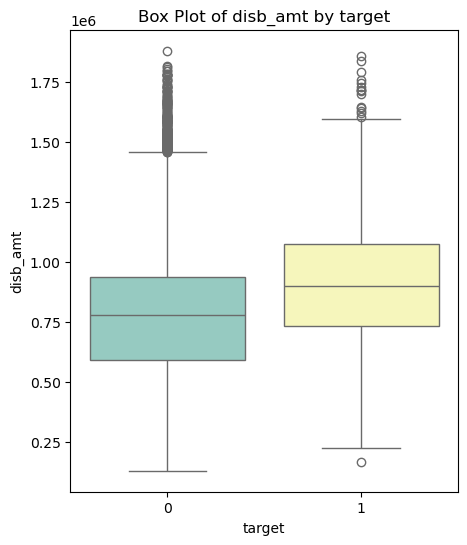

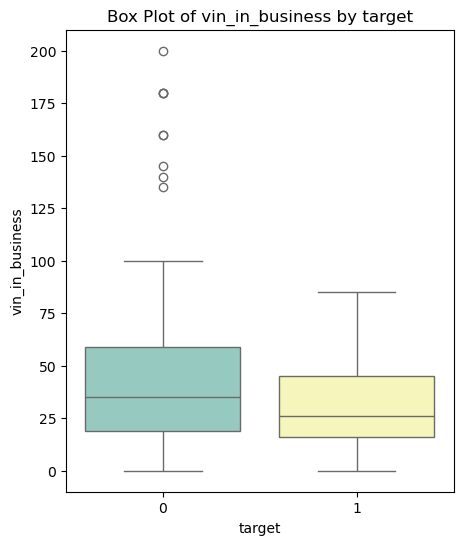

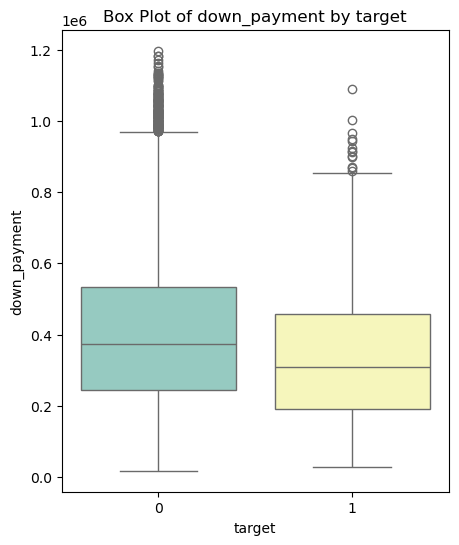

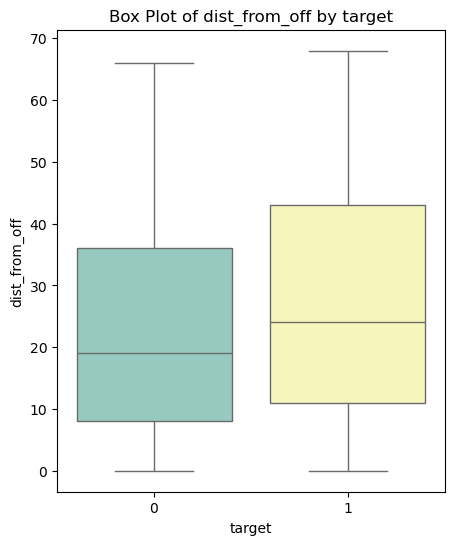

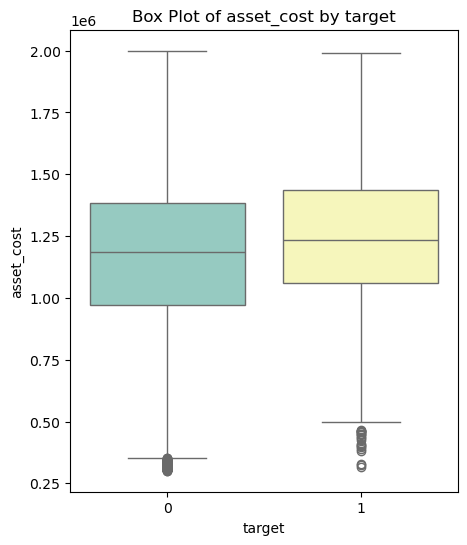

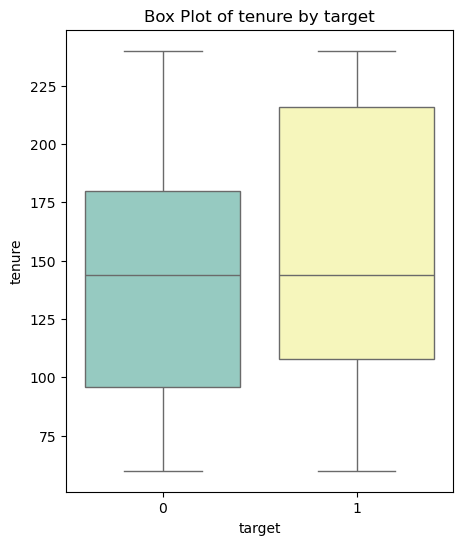

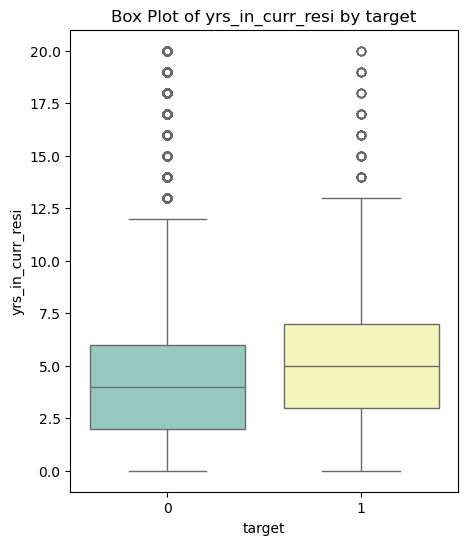

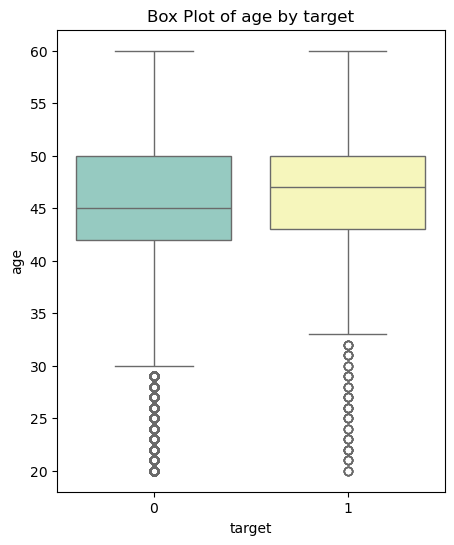

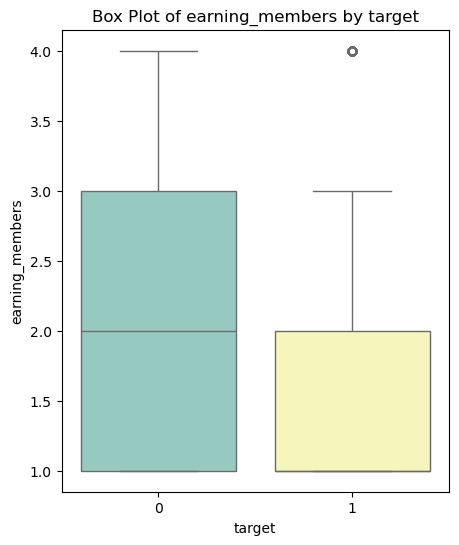

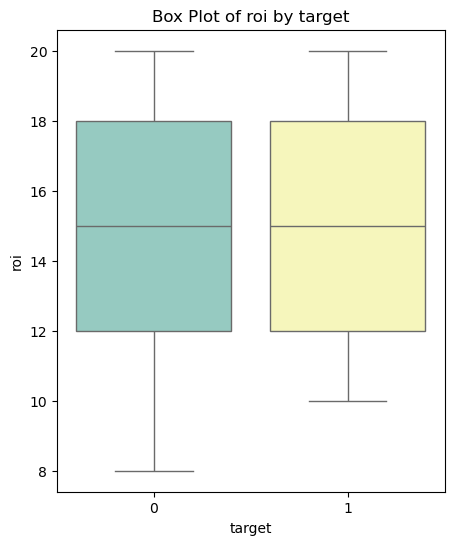

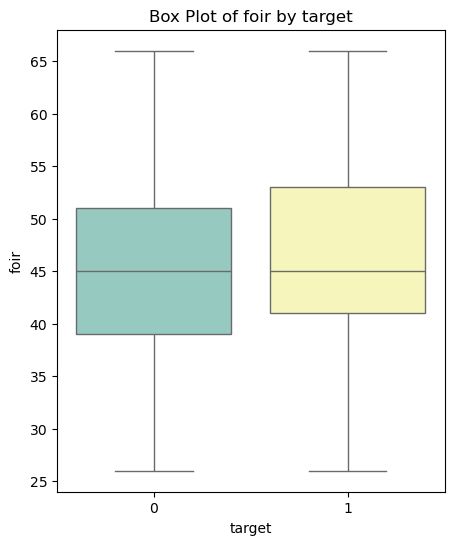

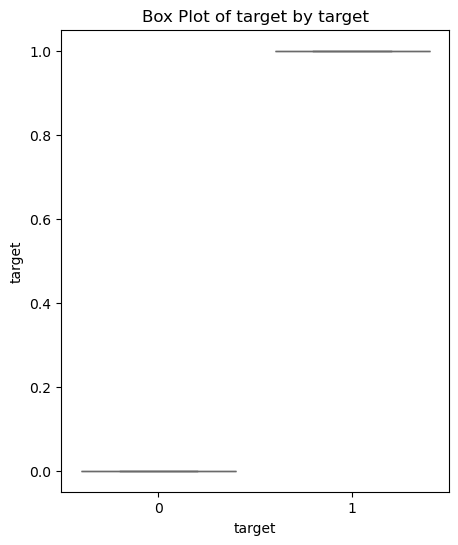

In [138]:
for col in new_df.columns:    
    plt.figure(figsize=(5, 6))
    sns.boxplot(data=new_df, x='target', y=col, palette="Set3")  # If you have a category column
    # Or, if you want to plot a single column without grouping:
#     sns.boxplot(y=df[col], palette="Set3")
    
    plt.title(f"Box Plot of {col} by target")
    plt.xlabel("target")
    plt.ylabel(f"{col}")
    plt.show()

Outliers--> disb_amt, vin_in_business, down_payment, asset_cost, yrs_in_curr_resi, age, earning_members

### WOE转换

In [139]:
df_woe = new_df.copy()

# Loop through each feature and substitute WOE values
for feature, woe_df in feature_df.items():
    # Get the WOE map for this feature
    woe_map = dict(zip(woe_df.index, woe_df['woe']))
    if feature in new_df.columns:

        # Check if the feature is continuous (has been binned) or categorical
        if feature + '_binned' in dev.columns:
            # Continuous: map WOE using binned column
            binned_feature = feature + '_binned'
            df_woe[feature] = dev[binned_feature].map(woe_map)
        else:
            # Categorical: map WOE directly on the original column
            df_woe[feature] = dev[feature].map(woe_map)

# Display the WOE-substituted DataFrame
print("DataFrame with WOE-substituted values:")
df_woe.head()

DataFrame with WOE-substituted values:


,ltv,disb_amt,vin_in_business,down_payment,dist_from_off,asset_cost,tenure,yrs_in_curr_resi,age,earning_members,roi,foir,target
0,-0.286088,-0.265407,0.016742,0.079022,-0.063234,0.259548,-0.300534,-0.353589,-0.074352,0.576999,-0.024215,-0.018646,0
1,0.561765,0.259548,-0.469665,-0.017021,0.145695,0.112905,0.085412,-0.075575,-0.186933,-0.050027,-0.058179,-0.018646,0
2,0.058249,-0.406486,0.273758,0.574343,-0.072867,-0.047345,0.357135,-0.075575,0.107003,-0.060547,0.104340,0.028628,0
3,-0.578603,0.014115,-0.105381,-0.406486,-0.138222,-0.105732,-0.219023,-0.029082,-0.017521,-0.060547,0.104340,-0.018646,0
4,-0.005863,0.079022,0.566375,-0.017021,0.284602,0.014115,-0.062109,-0.075575,0.167274,-0.060547,0.182535,-0.021980,0


In [140]:
df_woe.dropna(inplace = True)

In [141]:
for col in df_woe.select_dtypes(include='category').columns:
    df_woe[col]= df_woe[col].astype('float')


In [142]:
df_woe.shape

(10000, 13)

In [143]:
# new_df["age"].head(30)

####  WOE 特征的 VIF 计算

In [144]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_woe), columns=df_woe.columns)

# Calculating VIF for each variable
vif_data_woe = pd.DataFrame()
vif_data_woe["Variable"] = df_scaled.columns
vif_data_woe["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

# Display VIF scores
print(vif_data_woe)

            Variable       VIF
0                ltv  2.554058
1           disb_amt  1.974777
2    vin_in_business  1.436324
3       down_payment  1.945676
4      dist_from_off  1.209525
5         asset_cost  1.579964
6             tenure  1.109349
7   yrs_in_curr_resi  1.430368
8                age  1.698288
9    earning_members  1.374403
10               roi  1.398815
11              foir  1.004034
12            target  1.056419


In [145]:
# df_woe.info()

In [146]:
df_woe.head()

,ltv,disb_amt,vin_in_business,down_payment,dist_from_off,asset_cost,tenure,yrs_in_curr_resi,age,earning_members,roi,foir,target
0,-0.286088,-0.265407,0.016742,0.079022,-0.063234,0.259548,-0.300534,-0.353589,-0.074352,0.576999,-0.024215,-0.018646,0
1,0.561765,0.259548,-0.469665,-0.017021,0.145695,0.112905,0.085412,-0.075575,-0.186933,-0.050027,-0.058179,-0.018646,0
2,0.058249,-0.406486,0.273758,0.574343,-0.072867,-0.047345,0.357135,-0.075575,0.107003,-0.060547,0.104340,0.028628,0
3,-0.578603,0.014115,-0.105381,-0.406486,-0.138222,-0.105732,-0.219023,-0.029082,-0.017521,-0.060547,0.104340,-0.018646,0
4,-0.005863,0.079022,0.566375,-0.017021,0.284602,0.014115,-0.062109,-0.075575,0.167274,-0.060547,0.182535,-0.021980,0


In [147]:
x_train = df_woe.drop('target', axis=1)
y_train = df_woe['target']

#### WOE transformation of validation data

In [148]:

# Function to apply WOE transformation based on training WOE values
def apply_woe_transformation(data, woe_mappings):
    """
    Transforms features in data using WOE values from woe_mappings.

    Parameters:
    data (DataFrame): Testing data to transform.
    woe_mappings (dict): Dictionary of WOE DataFrames for each feature.

    Returns:
    DataFrame: Transformed testing data with WOE values.
    """
    data_woe = data[new_df.columns].copy()
    
    for feature, woe_df in woe_mappings.items():
        # Get WOE mapping for this feature from training data
        woe_dict = dict(zip(woe_df.index, woe_df['woe']))
        if feature in data_woe.columns:
        # Apply WOE values to corresponding bins in the test set
            data_woe[feature] = data[feature].map(woe_dict)
    data_woe.dropna(inplace=True)
    return data_woe

# Example usage
# Assuming 'woe_mappings' contains WOE mappings for each feature
# woe_mappings = {'feature1': woe_iv_df1, 'feature2': woe_iv_df2, ...}

val_woe = apply_woe_transformation(val, feature_df)


In [149]:
val_woe['target'].sum()

427

In [150]:
val_woe.isnull().sum()

ltv                 0
disb_amt            0
vin_in_business     0
down_payment        0
dist_from_off       0
asset_cost          0
tenure              0
yrs_in_curr_resi    0
age                 0
earning_members     0
roi                 0
foir                0
target              0
dtype: int64

In [151]:
val_woe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5996 entries, 4394 to 7563
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ltv               5996 non-null   float64
 1   disb_amt          5996 non-null   float64
 2   vin_in_business   5996 non-null   float64
 3   down_payment      5996 non-null   float64
 4   dist_from_off     5996 non-null   float64
 5   asset_cost        5996 non-null   float64
 6   tenure            5996 non-null   float64
 7   yrs_in_curr_resi  5996 non-null   float64
 8   age               5996 non-null   float64
 9   earning_members   5996 non-null   float64
 10  roi               5996 non-null   float64
 11  foir              5996 non-null   float64
 12  target            5996 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 655.8 KB


In [152]:
val_woe.head()

,ltv,disb_amt,vin_in_business,down_payment,dist_from_off,asset_cost,tenure,yrs_in_curr_resi,age,earning_members,roi,foir,target
4394,0.688416,0.340728,1.051267,0.340728,-0.320830,0.046111,0.070438,-0.029082,0.167274,-0.060547,0.182535,-0.139857,0
18882,0.249584,0.340728,-0.301125,-0.047345,-0.138222,-0.290076,-0.219023,-0.354710,-0.110070,0.576999,-0.119638,-0.101592,0
14936,1.441844,0.523468,0.317914,0.574343,0.070438,-0.214511,0.357135,0.189266,-0.017521,-0.060547,-0.058179,0.028628,0
978,-0.286088,0.428312,0.016742,0.112905,0.029837,0.046111,-0.300534,0.189266,-0.017521,-0.060547,-0.243785,-0.021980,0
8235,1.083605,0.943441,1.500113,0.079022,-0.138222,0.574343,0.439961,0.168265,0.167274,-0.060547,0.211517,-0.112695,0


In [153]:
x_test = val_woe.drop('target', axis=1)
y_test = val_woe['target'].to_numpy()

In [154]:
x_test.shape

(5996, 12)

In [155]:
y_test.shape

(5996,)

## 建模

In [156]:
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [157]:
# y_pred = log_reg.predict(x_test)
# y_pred

In [158]:
y_proba = log_reg.predict_proba(x_test)[:,1]
y_proba

array([0.02552689, 0.05409445, 0.01535935, ..., 0.03691605, 0.06472711,
       0.07617306])

In [159]:
y_proba.shape

(5996,)

In [160]:
# Selected probability threshold as 0.10 by reference of the Decile Analysis.
y_pred = (y_proba > 0.10).astype(int)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

# 模型训练

In [161]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.7701801200800533
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.87      5569
           1       0.15      0.48      0.23       427

    accuracy                           0.77      5996
   macro avg       0.55      0.63      0.55      5996
weighted avg       0.89      0.77      0.82      5996



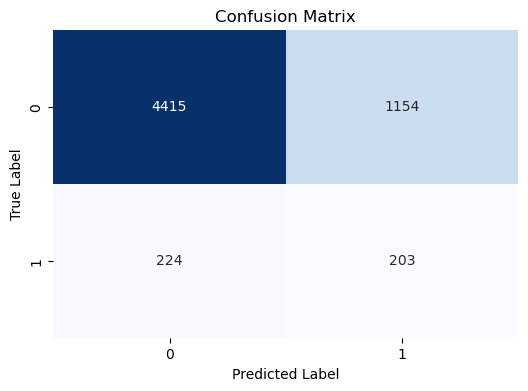

In [162]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

###  十分位分析

In [163]:

def decile_analysis(predicted_prob, actual_target):
    # Create a DataFrame to store the results
    df = pd.DataFrame({'predicted_prob': predicted_prob, 'actual_target': actual_target})
    
    # Sort by predicted probability in descending order
    df = df.sort_values(by='predicted_prob', ascending=False).reset_index(drop=True)
    
    # Assign each row to a decile
    df['decile'] = pd.qcut(df.index + 1, 10, labels=range(1, 11))
    
    # Group by decile and calculate metrics
    decile_df = df.groupby('decile').apply(
        lambda x: pd.Series({
            'No. of customers': len(x),
            'Defaulters': x['actual_target'].sum(),
            'Default Rate': x['actual_target'].mean() * 100,  # In percentage
            'Probability Range': f"{x['predicted_prob'].min():.2f}-{x['predicted_prob'].max():.2f}"
        })
    ).reset_index()

    # Calculate cumulative metrics and lift
    decile_df['Cumulative Customers'] = decile_df['No. of customers'].cumsum()
    decile_df['Cumulative % of customers'] = (decile_df['Cumulative Customers'] / decile_df['No. of customers'].sum()) * 100
    decile_df['% of Defaulters'] = (decile_df['Defaulters'] / decile_df['Defaulters'].sum()) * 100
    decile_df['Cumulative Defaulters'] = decile_df['Defaulters'].cumsum()
    decile_df['Cumulative % of Defaulters or Gain'] = (decile_df['Cumulative Defaulters'] / decile_df['Defaulters'].sum()) * 100
    decile_df['Lift'] = decile_df['Default Rate'] / (df['actual_target'].mean() * 100)  # Compare with overall response rate

    # Round values for cleaner presentation
    decile_df = decile_df.round(2)

    return decile_df

# `y_proba` is the predicted probabilities and `y_test` is the actual target in the test set
# Replace y_proba and y_test with your actual variables
decile_table = decile_analysis(y_proba, y_test)
print(decile_table)


  decile  No. of customers  Defaulters  Default Rate Probability Range  \
0      1               600         109         18.17         0.16-0.51   
1      2               600          79         13.17         0.11-0.16   
2      3               599          58          9.68         0.08-0.11   
3      4               600          30          5.00         0.06-0.08   
4      5               599          46          7.68         0.05-0.06   
5      6               600          33          5.50         0.04-0.05   
6      7               599          16          2.67         0.03-0.04   
7      8               600          21          3.50         0.02-0.03   
8      9               599          20          3.34         0.01-0.02   
9     10               600          15          2.50         0.00-0.01   

   Cumulative Customers  Cumulative % of customers  % of Defaulters  \
0                   600                      10.01            25.53   
1                  1200                    

### 风控模型可视化

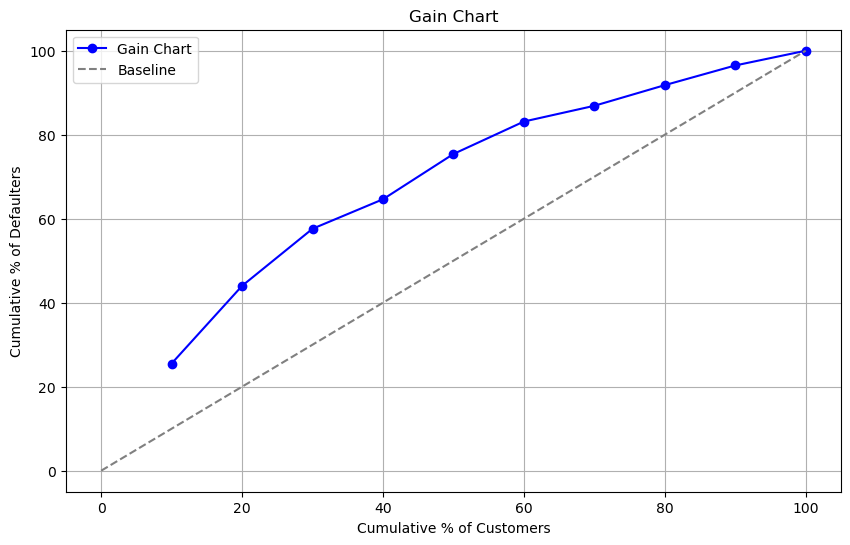

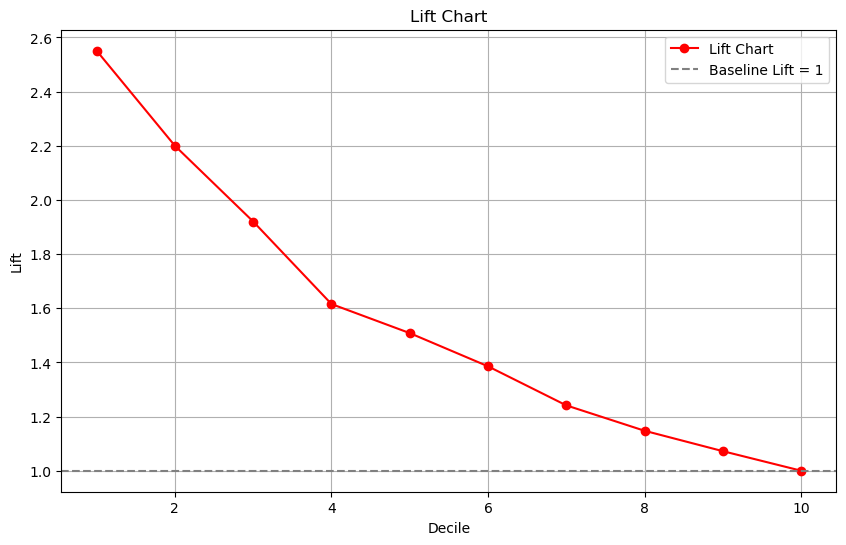

In [164]:

def lift_gain_chart(predicted_prob, actual_target, n_bins=10):
    # Create a DataFrame to store predicted probabilities and actual target values
    df = pd.DataFrame({'predicted_prob': predicted_prob, 'actual_target': actual_target})
    
    # Sort by predicted probabilities in descending order
    df = df.sort_values(by='predicted_prob', ascending=False).reset_index(drop=True)
    
    # Create deciles based on the sorted probabilities
    df['decile'] = pd.qcut(df.index + 1, n_bins, labels=range(1, n_bins + 1))
    
    # Calculate metrics by decile
    decile_df = df.groupby('decile').apply(
        lambda x: pd.Series({
            'No. of customers': len(x),
            'Defaulters': x['actual_target'].sum(),
        })
    ).reset_index()
    
    # Calculate cumulative gains and lift
    decile_df['Cumulative Defaulters'] = decile_df['Defaulters'].cumsum()
    decile_df['Cumulative % of Defaulters'] = decile_df['Cumulative Defaulters'] / decile_df['Defaulters'].sum() * 100
    decile_df['Cumulative % of Customers'] = decile_df['No. of customers'].cumsum() / decile_df['No. of customers'].sum() * 100
    decile_df['Lift'] = decile_df['Cumulative % of Defaulters'] / decile_df['Cumulative % of Customers']
    
    # Plot the Gain Chart
    plt.figure(figsize=(10, 6))
    plt.plot(decile_df['Cumulative % of Customers'], decile_df['Cumulative % of Defaulters'], marker='o', color='b', label='Gain Chart')
    plt.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Baseline')
    plt.xlabel('Cumulative % of Customers')
    plt.ylabel('Cumulative % of Defaulters')
    plt.title('Gain Chart')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot the Lift Chart
    plt.figure(figsize=(10, 6))
    plt.plot(decile_df['decile'], decile_df['Lift'], marker='o', color='r', label='Lift Chart')
    plt.axhline(y=1, color='gray', linestyle='--', label='Baseline Lift = 1')
    plt.xlabel('Decile')
    plt.ylabel('Lift')
    plt.title('Lift Chart')
    plt.legend()
    plt.grid(True)
    plt.show()

# `y_proba` is the predicted probabilities and `y_test` is the actual target in the test set
# Replace y_proba and y_test with your actual variables
lift_gain_chart(y_proba, y_test)


### KS & Gini 计算

In [165]:

def ks_gini_score(y_true, y_pred_proba):
    # KS Score Calculation
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks_score = max(tpr - fpr)  # KS statistic is the max difference between TPR and FPR
    
    # Gini Score Calculation
    auc = roc_auc_score(y_true, y_pred_proba)
    gini_score = 2 * auc - 1  # Gini coefficient formula

    print(f"KS Score: {ks_score:.4f}")
    print(f"Gini Score: {gini_score:.4f}")

    return ks_score, gini_score

# y_test is the true labels and y_proba are the predicted probabilities
# Replace y_test and y_proba with your actual data
ks_score, gini_score = ks_gini_score(y_test, y_proba)


KS Score: 0.3021
Gini Score: 0.3863


### ROC_AUC 曲线

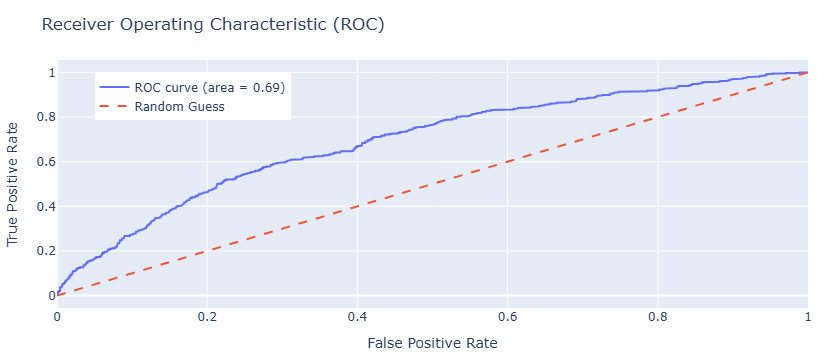

In [166]:


# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Create ROC curve plotly figure
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC curve (area = %0.2f)' % roc_auc))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random Guess'))

# Update layout
fig.update_layout(
    title='Receiver Operating Characteristic (ROC)',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    legend=dict(x=0.05, y=0.95),
    margin=dict(l=20, r=20, t=60, b=20),
    hovermode='closest'
)

# Show plot
fig.show()

# 评分计算

In [167]:
logit_values = log_reg.decision_function(x_test)
logit_values

array([-3.6421646 , -2.86141121, -4.16055245, ..., -3.2614942 ,
       -2.67065818, -2.4955169 ])

In [168]:
log_odds = log_reg.intercept_ + np.dot(x_test, log_reg.coef_.T)

In [169]:
log_odds

array([[-3.6421646 ],
       [-2.86141121],
       [-4.16055245],
       ...,
       [-3.2614942 ],
       [-2.67065818],
       [-2.4955169 ]])

In [170]:

# Parameters for score calculation
offset = 600  
PDO = 20         

# Factor calculation
factor = PDO / np.log(2)

# Function to calculate the score based on log-odds
def calculate_score(model, X, offset=offset, factor=factor):
    # Calculate log-odds
    log_odds = model.intercept_ + np.dot(X, model.coef_.T)
    
    # Convert log-odds to score
    score = offset + (log_odds * factor)
    score = np.round(score).astype(int) 
    return score

# x_test is the test dataset with WOE-transformed features
# and `model` is the trained logistic regression model
scores = calculate_score(log_reg, x_test)

# Convert scores to a DataFrame for easy analysis and review
score_df = pd.DataFrame({'Score': scores.flatten()})
print(score_df.head())

# Optionally, save the scores to an Excel file
# score_df.to_excel('calculated_scores.xlsx', index=False)


   Score
0    495
1    517
2    480
3    530
4    456


In [171]:
sum(score_df['Score']>600)

2

# 利润分析

In [172]:
# val.head()

In [173]:
before_model=pd.DataFrame(val['disb_amt']*val['roi']/100, columns=['interest_inc']) #Interest Income
before_model['total_amt']=val['disb_amt']*(100+val['roi'])/100   #Interest + principal amount

In [174]:
profit_cal=pd.concat([before_model,val[['disb_amt','roi']]], axis=1)

In [175]:
y_test1 = pd.Series(y_test, index=profit_cal.index[:len(y_test)])
profit_cal['target']=y_test1.reindex(profit_cal.index)
profit_cal.dropna(inplace=True)
profit_cal['target'] = profit_cal['target'].astype('int64')

In [176]:
profit_cal.head()

,interest_inc,total_amt,disb_amt,roi,target
4394,89843.21,562702.21,472859,19,0
18882,92748.12,865649.12,772901,12,0
14936,99914.70,766012.70,666098,15,0
978,72194.10,794135.10,721941,10,0
8235,36517.50,239392.50,202875,18,0


In [177]:
profit_cal.shape

(5996, 5)

In [178]:
print("Total disburesment amount:", profit_cal['disb_amt'].sum())
print("Total expected interest amount:", profit_cal['interest_inc'].sum())
print("Total amount should be recovered:", profit_cal['total_amt'].sum()) # principal + interest

Total disburesment amount: 4712881161
Total expected interest amount: 714859647.75
Total amount should be recovered: 5427740808.75


### 模型上线前利润计算

In [179]:
print("Total Non-Defaulted interest income:", profit_cal[profit_cal['target']==0]['interest_inc'].sum() )
print("Yet to recover interest amount:", profit_cal['interest_inc'].sum() - profit_cal[profit_cal['target']==0]['interest_inc'].sum() )
# Assuming the extream case where the defaulted amount is disbursment amount
woi = profit_cal[profit_cal['target']==1]['disb_amt'].sum() # Only Principal (Without interest)
print("Total Defaulted disbursment amount:", woi) 
# principal + interest for defaulted customers
wi = profit_cal[profit_cal['target']==1]['interest_inc'].sum() + profit_cal[profit_cal['target']==1]['disb_amt'].sum() #(with interest)
print("Total Defaulted amount should be recovered:", wi) 

Total Non-Defaulted interest income: 661866676.87
Yet to recover interest amount: 52992970.879999995
Total Defaulted disbursment amount: 347270603
Total Defaulted amount should be recovered: 400263573.88


In [180]:
profit_b_model_woi = profit_cal[profit_cal['target']==0]['interest_inc'].sum() - woi

In [181]:
profit_b_model_wi = profit_cal[profit_cal['target']==0]['interest_inc'].sum() - wi

In [182]:
print("Total profit before applying model (excluding interest):", profit_b_model_woi)
print("Total profit before applying model (including interest):", profit_b_model_wi)

Total profit before applying model (excluding interest): 314596073.87
Total profit before applying model (including interest): 261603102.99


In [183]:
print("Percentage of profit on investment - ROI (excluding interest):", (profit_b_model_woi/profit_cal['disb_amt'].sum())*100, "%")
print("Percentage of profit on investment - ROI (including interest):", (profit_b_model_wi/profit_cal['disb_amt'].sum())*100, "%")

Percentage of profit on investment - ROI (excluding interest): 6.675238842713522 %
Percentage of profit on investment - ROI (including interest): 5.5508105138490675 %


### 模型上线后

In [184]:
y_predicted = pd.Series(y_pred, index=profit_cal.index[:len(y_pred)])
profit_cal['predicted'] = y_predicted.reindex(profit_cal.index)
profit_cal['predicted']=profit_cal['predicted'].astype('int64')

In [185]:
profit_cal['Category'] = None
profit_cal.loc[(profit_cal['target'] == 1) & (profit_cal['predicted'] ==1), 'Category'] = 'TP'
profit_cal.loc[(profit_cal['target'] == 0) & (profit_cal['predicted'] ==0), 'Category'] = 'TN'
profit_cal.loc[(profit_cal['target'] == 0) & (profit_cal['predicted'] ==1), 'Category'] = 'FP'
profit_cal.loc[(profit_cal['target'] == 1) & (profit_cal['predicted'] ==0), 'Category'] = 'FN'

In [186]:
profit_cal['Category'].value_counts()

Category
TN    4415
FP    1154
FN     224
TP     203
Name: count, dtype: int64

###### Without defaulter interest calculation

In [187]:
TN_in = profit_cal[profit_cal['Category']=='TN']['interest_inc'].sum()
TP_in = profit_cal[profit_cal['Category']=='TP']['disb_amt'].sum() 
FN_out = profit_cal[profit_cal['Category']=='FN']['disb_amt'].sum() 
FP_out = profit_cal[profit_cal['Category']=='FP']['interest_inc'].sum() 

In [188]:
print("Total incoming interest from truly identified non-defaulters:", TN_in)
print("Profit from truly identifying defaulters (excluding interest):", TP_in)
print("Loss from fail to identify defaulters (excluding interest):", FN_out)
print("Loss incurring from fail to identify non_defaulters:", FP_out)

Total incoming interest from truly identified non-defaulters: 514932348.59
Profit from truly identifying defaulters (excluding interest): 166424143
Loss from fail to identify defaulters (excluding interest): 180846460
Loss incurring from fail to identify non_defaulters: 146934328.28


###### With defaulter interest calculation

In [189]:
TP_in_wi = profit_cal[profit_cal['Category']=='TP']['interest_inc'].sum() + TP_in
FN_out_wi = profit_cal[profit_cal['Category']=='FN']['interest_inc'].sum() + FN_out
print("Profit from truly identifying defaulters (including interest):", TP_in_wi)
print("Loss from fail to identify defaulters (including interest):", FN_out_wi)

Profit from truly identifying defaulters (including interest): 191315958.55
Loss from fail to identify defaulters (including interest): 208947615.32999998


In [190]:
profit_a_model_woi = TN_in + TP_in - FN_out - FP_out  # Without interest

In [191]:
profit_a_model_wi = TN_in + TP_in_wi - FN_out_wi - FP_out  # With interest

In [192]:
print("Total profit after applying model (excluding interest):", profit_a_model_woi)
print("Total profit after applying model (including interest):", profit_a_model_wi)

Total profit after applying model (excluding interest): 353575703.30999994
Total profit after applying model (including interest): 350366363.53


In [193]:
print("Percentage of profit on investment - ROI (excluding interest):", (profit_a_model_woi/profit_cal['disb_amt'].sum())*100, "%")
print("Percentage of profit on investment - ROI (including interest):", (profit_a_model_wi/profit_cal['disb_amt'].sum())*100, "%")

Percentage of profit on investment - ROI (excluding interest): 7.502325885827697 %
Percentage of profit on investment - ROI (including interest): 7.434228692829116 %


### 额外利润

In [194]:
net_profit_woi = profit_a_model_woi - profit_b_model_woi

In [195]:
net_profit_wi = profit_a_model_wi - profit_b_model_wi

In [196]:
print("NET PROFIT (excluding interest):", net_profit_woi)
print("NET PROFIT (including interest):", net_profit_wi)

NET PROFIT (excluding interest): 38979629.43999994
NET PROFIT (including interest): 88763260.53999996


### 业务利润增长率

In [197]:
print('Percentage of growth in business (excluding interest):', (net_profit_woi/profit_b_model_woi)*100,"%")
print('Percentage of growth in business (including interest):', (net_profit_wi/profit_b_model_wi)*100,"%")

Percentage of growth in business (excluding interest): 12.390373776917325 %
Percentage of growth in business (including interest): 33.93050752283814 %
